# Symptom-Based Disease Prediction System

### Description

The **Symptom-Based Disease Prediction System** is a machine learning-powered application designed to assist in the early identification of diseases based on user-reported symptoms. The system uses a dataset of diseases and their associated symptoms to build a predictive model. Users can input their symptoms, and the model predicts the most likely diseases along with confidence scores.

### Key Features:

- **Symptom Input:** Users provide a list of symptoms they are experiencing.
- **Top Disease Predictions:** The system returns the top three most probable diseases with confidence percentages.
- **Visualization:** Confusion matrix and other evaluation metrics help understand model performance.
- **Reusable Model:** The trained model and encoders can be saved and loaded for future predictions without retraining.
- **Machine Learning Backend:** Uses a Random Forest classifier to handle multi-class disease prediction efficiently.



In [ ]:
import joblib

# 1. Import libraries and Load dataset
- Import required libraries

- Load and shuffle the dataset

- Normalize and clean text data

- Handle duplicate data

In [ ]:
# ===============================
#  IMPORTS
# ===============================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ===============================
#  LOAD DATASET
# ===============================
df = pd.read_csv('/content/dataset.csv')

print(f"Original Dataset size: {df.shape}")
print(f"Original dataset:\n {df.head()}")
print("\n")

# ===============================
#  CHECK EMPTY ROWS
# ===============================
empty_rows = df.isna().all(axis=1).sum()
print(f"Number of completely empty rows = {empty_rows}")
print("\n")

# ===============================
#  NORMALIZE TEXT
# ===============================
for col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

df = df.replace('nan', np.nan)

print(f"Disease list:\n {df['Disease'].unique()}")
print("\n")

# ===============================
#  REMOVE ORDER-INSENSITIVE DUPLICATES

# Example of order-insensitive duplicates:
# These two records are considered duplicates because they contain the same symptoms,
# even though the order of symptoms in the columns is different.

# Record 1:
# Disease = "flu", Symptoms = [fever, cough, fatigue]

# Record 2:
# Disease = "flu", Symptoms = [cough, fatigue, fever]

# Since the set of symptoms is identical, these rows represent the same information
# and should be treated as duplicates during preprocessing.
# ===============================
symptom_cols = [col for col in df.columns if "Symptom" in col]

def normalize_symptoms(row):
    symptoms = []
    for s in row[symptom_cols]:
        if pd.notna(s):
            symptoms.append(s)

    # remove duplicates + sort (order independent)
    symptoms = sorted(set(symptoms))
    return tuple(symptoms)

# Create normalized representation
df["normalized_symptoms"] = df.apply(normalize_symptoms, axis=1)

# Remove duplicates based on Disease + normalized symptoms
before = df.shape[0]
df = df.drop_duplicates(subset=["Disease", "normalized_symptoms"])
after = df.shape[0]

# ===============================
#  DROP HELPER COLUMN
# ===============================
df = df.drop(columns=["normalized_symptoms"])

print(f"Removed {before - after} duplicate rows")
print(f"Dataset size after deduplication: {df.shape}")
print("\n")

# ===============================
#  EXTRACT SYMPTOMS LIST
# ===============================
symptoms = pd.unique(df[symptom_cols].values.ravel())

# Remove empty values
symptoms = [s for s in symptoms if pd.notna(s) and s != ""]

print(f"Symptoms list:\n {symptoms}")
print("\n")

print(f"Number of diseases: {df['Disease'].nunique()}")
print(f"Number of symptoms: {len(symptoms)}")
print("\n")

print(f"Cleaned dataset:\n {df.head()}")
print(f"Final dataset size: {df.shape}")

/tmp/ipykernel_7266/1142790300.py:18: DtypeWarning: Columns (15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/dataset.csv')


Original Dataset size: (54920, 18)
Original dataset:
             Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN 

In [ ]:
df.describe()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
count,16857,16857,16857,16857,16791,16606,16007,14428,11179,7430,4062,1823,682,185,34,18,10,1
unique,41,226,227,226,228,226,224,222,218,210,184,135,107,55,17,3,3,1
top,hypothyroidism,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,fatigue,depression,chest_pain,blood_in_sputum,muscle_pain,muscle_pain
freq,911,1325,1301,1315,1228,1248,1211,1081,875,594,311,130,55,11,16,8,8,1


# 2. Extract All Unique Symptoms

This section of the code identifies and indexes all unique symptoms present in the dataset.  
The resulting symptom list is later used for feature encoding in the disease prediction model.


In [ ]:
symptom_columns = df.columns[1:]

all_symptoms = set()
for col in symptom_columns:
    all_symptoms.update(df[col].dropna())

all_symptoms = sorted(all_symptoms)
print("Total symptoms:", len(all_symptoms))
print("\n")

symptom_index = {symptom: idx for idx, symptom in enumerate(all_symptoms)}
symptom_index


Total symptoms: 233




{'abdominal_pain': 0,
 'abnormal_menstruation': 1,
 'acidity': 2,
 'acute_liver_failure': 3,
 'agitation': 4,
 'altered_sensorium': 5,
 'anxiety': 6,
 'back_pain': 7,
 'back_stiffness': 8,
 'bad_breath': 9,
 'belly_pain': 10,
 'blackheads': 11,
 'bladder_discomfort': 12,
 'blister': 13,
 'blistering': 14,
 'bloating': 15,
 'blood_in_sputum': 16,
 'blood_in_urine': 17,
 'bloody_stool': 18,
 'bluish_lips': 19,
 'blurred_and_distorted_vision': 20,
 'bone_pain': 21,
 'bone_tenderness': 22,
 'brain_fog': 23,
 'breathlessness': 24,
 'brittle_nails': 25,
 'bruising': 26,
 'burning_micturition': 27,
 'chest_pain': 28,
 'chest_tightness': 29,
 'chills': 30,
 'chills_with_rigor': 31,
 'cloudy_urine': 32,
 'cold_extremities': 33,
 'cold_hands_and_feets': 34,
 'cold_intolerance': 35,
 'cold_sweats': 36,
 'coma': 37,
 'confusion': 38,
 'congestion': 39,
 'constipation': 40,
 'continuous_feel_of_urine': 41,
 'continuous_sneezing': 42,
 'cough': 43,
 'cramps': 44,
 'dark_circles': 45,
 'dark_urine': 

# 3. Create a Multi-Hot Encoded Feature Matrix

This section converts symptom data into a numerical feature matrix that can be used as input for the machine learning model.  

Each row represents a patient (or record), and each column represents a unique symptom.

Each symptom is encoded '1' if that symptom is present in the patient record else encoded '0'.


In [ ]:
X = np.zeros((len(df), len(all_symptoms)))
df = df.reset_index(drop=True)

for i, row in df.iterrows():
    for col in symptom_columns:
        symptom = row[col]
        if pd.notna(symptom):
            X[i, symptom_index[symptom]] = 1

pd.DataFrame(X)


,0,1,2,3,4,5,6,7,8,9,...,223,224,225,226,227,228,229,230,231,232
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
16853,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# 4. Encode Disease Labels

This section converts disease names (categorical labels) into numerical form so they can be used as target values for machine learning model training.
For example:
flu → 0,
migraine → 1,
diabetes → 2


In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['Disease'])

print("Total diseases:", len(le.classes_))
le.classes_

Total diseases: 41


array(['(vertigo) paroymsal  positional vertigo', 'acne', 'aids',
       'alcoholic hepatitis', 'allergy', 'arthritis', 'bronchial asthma',
       'cervical spondylosis', 'chicken pox', 'chronic cholestasis',
       'common cold', 'dengue', 'diabetes',
       'dimorphic hemmorhoids(piles)', 'drug reaction',
       'fungal infection', 'gastroenteritis', 'gerd', 'heart attack',
       'hepatitis a', 'hepatitis b', 'hepatitis c', 'hepatitis d',
       'hepatitis e', 'hypertension', 'hyperthyroidism', 'hypoglycemia',
       'hypothyroidism', 'impetigo', 'jaundice', 'malaria', 'migraine',
       'osteoarthristis', 'paralysis (brain hemorrhage)',
       'peptic ulcer diseae', 'pneumonia', 'psoriasis', 'tuberculosis',
       'typhoid', 'urinary tract infection', 'varicose veins'],
      dtype=object)

# 5. Train–Test Split Using Stratified Sampling

This section splits the dataset into training and testing sets.  
Stratified splitting ensures that each disease appears proportionally in training and testing set.


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(sss.split(X, y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"train size: {len(x_train)}")
print(f"test size: {len(x_test)}")

print("\n")

count_df = pd.DataFrame({
    "Disease": le.inverse_transform(range(0,41)),
    "Full Dataset": pd.Series(y).value_counts(),
    "Training Set": pd.Series(y_train).value_counts(),
    "Test Set": pd.Series(y_test).value_counts()
}).fillna(0)

count_df



train size: 13485
test size: 3372




,Disease,Full Dataset,Training Set,Test Set
0,(vertigo) paroymsal positional vertigo,103,82,21
1,acne,22,18,4
2,aids,607,486,121
3,alcoholic hepatitis,340,272,68
4,allergy,698,558,140
5,arthritis,493,394,99
6,bronchial asthma,266,213,53
7,cervical spondylosis,495,396,99
8,chicken pox,293,234,59
9,chronic cholestasis,261,209,52


# 6. Train the Random Forest Model with Decision tree as Baseline model

This section trains a Decision tree and Random Forest classifier on the encoded symptom data and evaluates its performance on the test dataset.

In [ ]:
# ================== BASELINE: DECISION TREE (NO TUNING) ==================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Define the baseline model (single tree, same class_weight balancing)
dt_baseline = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=None,        # fully grown tree
    min_samples_leaf=1,
)

# Train the model
dt_baseline.fit(x_train, y_train)

# Predict on test set
baseline_preds = dt_baseline.predict(x_test)

# Print results
print("=== DECISION TREE BASELINE ===")
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, baseline_preds) * 100))
print(classification_report(y_test, baseline_preds, target_names=le.classes_))

=== DECISION TREE BASELINE ===
Test Accuracy: 87.19%
                                         precision    recall  f1-score   support

(vertigo) paroymsal  positional vertigo       1.00      1.00      1.00        21
                                   acne       1.00      0.75      0.86         4
                                   aids       1.00      0.98      0.99       121
                    alcoholic hepatitis       1.00      1.00      1.00        68
                                allergy       1.00      1.00      1.00       140
                              arthritis       0.00      0.00      0.00        99
                       bronchial asthma       1.00      0.98      0.99        53
                   cervical spondylosis       0.37      1.00      0.54        99
                            chicken pox       1.00      0.98      0.99        59
                    chronic cholestasis       0.66      0.98      0.79        52
                            common cold       1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================== GRID SEARCH RANDOM FOREST ==================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the model
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")

# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 3, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy', # metric to optimize
    n_jobs=-1,          # use all CPU cores
)

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Get the best model
best_rf = grid_search.best_estimator_

# Predict on test set
preds = best_rf.predict(x_test)

# Print results
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.2f}%".format(grid_search.best_score_ * 100))
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, preds) * 100))

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV Accuracy: 97.05%
Test Accuracy: 96.68%


    param_max_depth  param_min_samples_leaf  param_n_estimators  \
0                 5                       1                  50   
1                 5                       1                 100   
2                 5                       1                 200   
3                 5                       2                  50   
4                 5                       2                 100   
5                 5                       2                 200   
6                 5                       3                  50   
7                 5                       3                 100   
8                 5                       3                 200   
9                 5                       4                  50   
10                5                       4                 100   
11                5                       4                 200   
12               10                       1                  50   
13               10                       1                 10

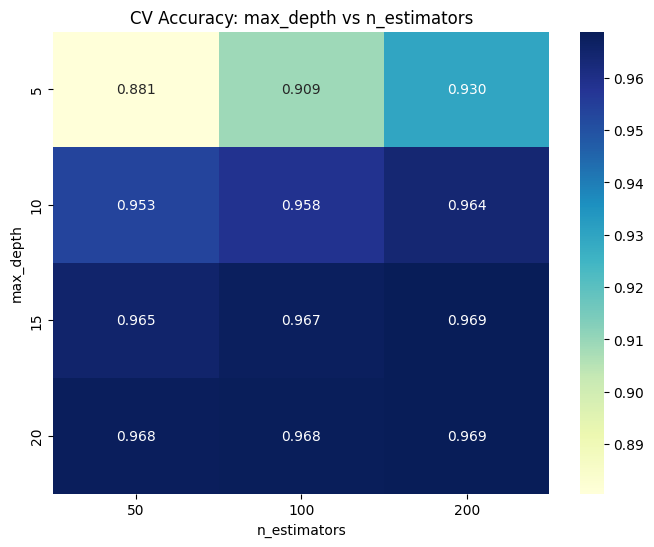

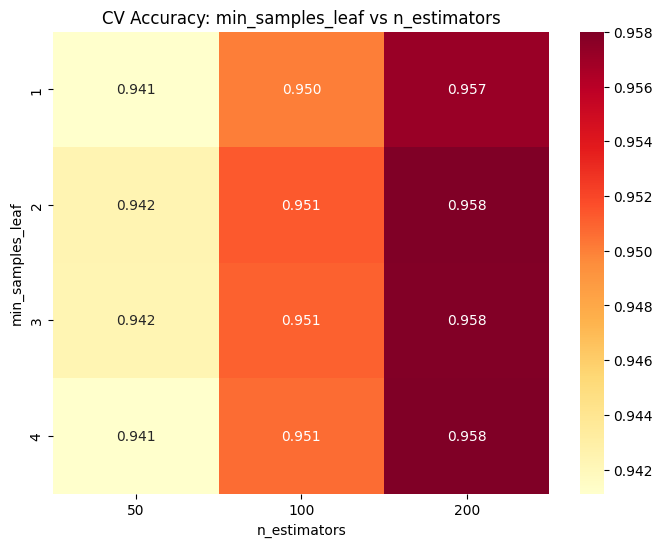

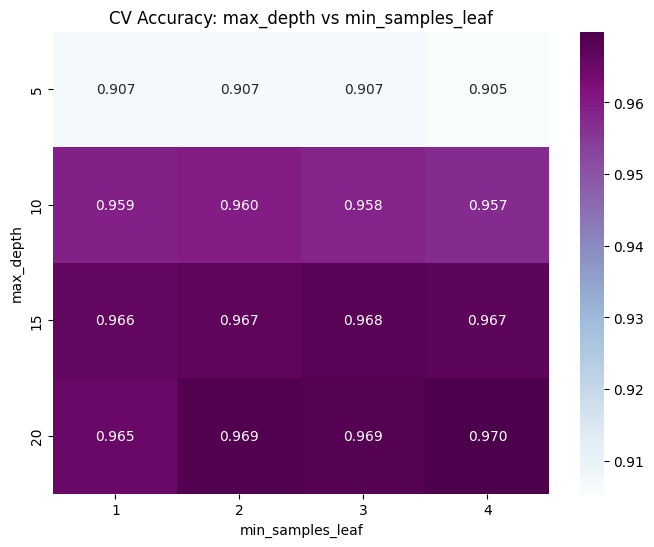

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert GridSearchCV results to DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Keep only relevant columns
results = results[['param_max_depth', 'param_min_samples_leaf', 'param_n_estimators', 'mean_test_score']]
print(results)

# ---- 1. Heatmap: n_estimators vs max_depth (aggregated over other params) ----
pivot1 = results.pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score',
    aggfunc='mean'
).sort_index(axis=0).sort_index(axis=1)  # ensure numeric ordering

plt.figure(figsize=(8,6))
sns.heatmap(pivot1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("CV Accuracy: max_depth vs n_estimators")
plt.ylabel("max_depth")
plt.xlabel("n_estimators")
plt.show()


# ---- 2. Heatmap: n_estimators vs min_samples_leaf (aggregated over other params) ----
pivot2 = results.pivot_table(
    index='param_min_samples_leaf',
    columns='param_n_estimators',
    values='mean_test_score',
    aggfunc='mean'
).sort_index(axis=0).sort_index(axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(pivot2, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("CV Accuracy: min_samples_leaf vs n_estimators")
plt.ylabel("min_samples_leaf")
plt.xlabel("n_estimators")
plt.show()


# ---- 3. Heatmap: max_depth vs min_samples_leaf (aggregated over other params) ----
pivot3 = results.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_leaf',
    values='mean_test_score',
    aggfunc='mean'
).sort_index(axis=0).sort_index(axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(pivot3, annot=True, fmt=".3f", cmap="BuPu")
plt.title("CV Accuracy: max_depth vs min_samples_leaf")
plt.ylabel("max_depth")
plt.xlabel("min_samples_leaf")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=le.classes_))

                                         precision    recall  f1-score   support

(vertigo) paroymsal  positional vertigo       1.00      1.00      1.00        21
                                   acne       1.00      1.00      1.00         4
                                   aids       1.00      0.99      1.00       121
                    alcoholic hepatitis       1.00      1.00      1.00        68
                                allergy       1.00      1.00      1.00       140
                              arthritis       0.96      0.99      0.98        99
                       bronchial asthma       1.00      0.96      0.98        53
                   cervical spondylosis       1.00      1.00      1.00        99
                            chicken pox       1.00      1.00      1.00        59
                    chronic cholestasis       0.76      0.92      0.83        52
                            common cold       1.00      1.00      1.00       153
                           

# 7. Confusion Matrix Visualization

This section evaluates the performance of the trained disease prediction model by visualizing the confusion matrix.  
The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each disease class.



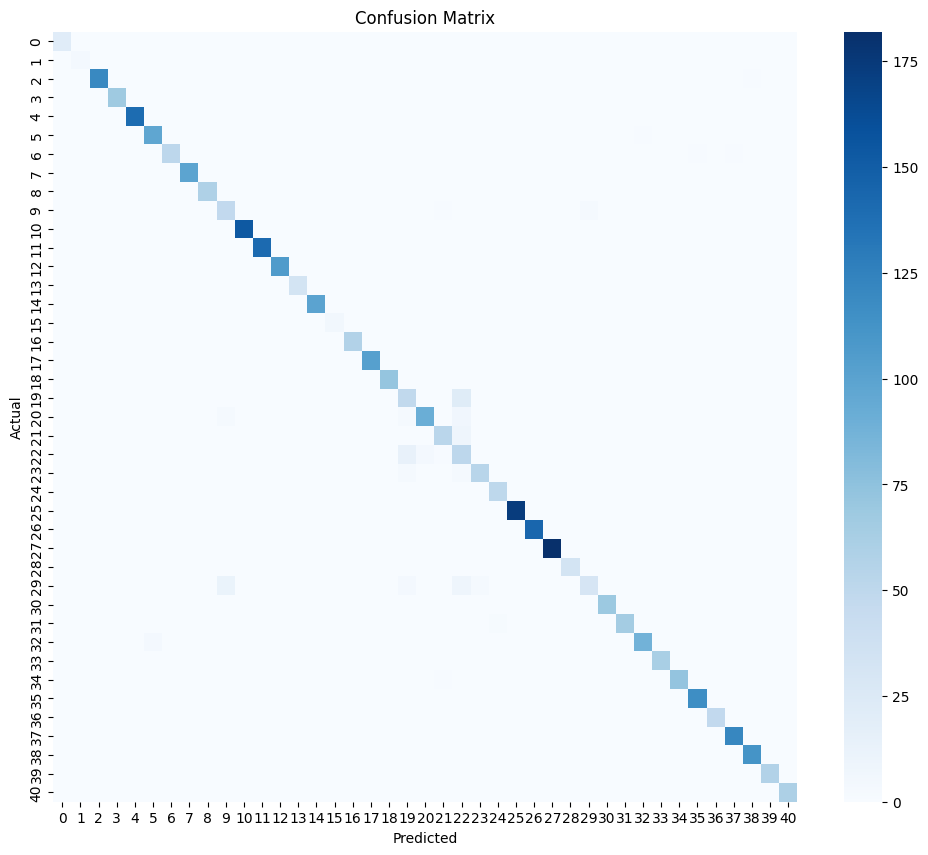

In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 8. Save the Trained Model and Encoders

This section saves the trained machine learning model and the associated encoders so that they can be reused later for prediction without retraining.



In [ ]:
joblib.dump(best_rf, "model.joblib")
joblib.dump(symptom_index, "symptom_index.joblib")
joblib.dump(le, "label_encoder.joblib")

print("Model and encoders saved.")


Model and encoders saved.


# 9. Load Saved Components and Define Disease Prediction Function

This section loads the saved model and encoders and defines a function to predict diseases based on a given list of symptoms.

In [ ]:
loaded_model = joblib.load("model.joblib")
loaded_symptom_index = joblib.load("symptom_index.joblib")
loaded_le = joblib.load("label_encoder.joblib")

def predict_disease(symptoms):
    x = np.zeros(len(loaded_symptom_index))

    for s in symptoms:
        s = s.lower().strip()
        if s in loaded_symptom_index:
            x[loaded_symptom_index[s]] = 1

    probs = loaded_model.predict_proba([x])[0]
    top = np.argsort(probs)[-3:][::-1]

    top_probs = probs[top]
    normalized = top_probs / top_probs.sum()

    results = []
    for idx, p in zip(top, normalized):
        results.append({
            "disease": loaded_le.inverse_transform([idx])[0],
            "confidence": round(p * 100, 2)
        })

    return results



# 10. Example Disease Prediction

This section demonstrates how to use the `predict_disease` function to generate disease predictions from a list of input symptoms. This function returns 3 most probable diseases along with their confidence levels based on input symptoms.


In [ ]:
predict_disease([
    "pus_filled_pimples",
    "blackheads",
    "skin_rash",
    "itching",
    "scurring",
    "skin_peeling",
    "red_spots_over_body",
    "blister",
    "dry_skin",
    "excessive_dryness"
])

[{'disease': 'acne', 'confidence': np.float64(56.57)},
 {'disease': 'psoriasis', 'confidence': np.float64(23.79)},
 {'disease': 'impetigo', 'confidence': np.float64(19.64)}]